###  Imports

In [3]:
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path

### Load Dataset

In [4]:
from data_loader import DataLoader

In [5]:
config_file = os.path.join('..',  'config', 'config.yaml')
loader = DataLoader(config_file)
df = loader.load_raw_data()

Data loaded successfully: (32581, 12)


### Step 1:  Schema Validation

In [6]:
print("Number of columns in the dataset:", df.shape[1])

Number of columns in the dataset: 12


In [7]:
expected_columns = [
"person_age"                 
,"person_income"            
,"person_home_ownership"      
,"person_emp_length"          
,"loan_intent"                
,"loan_grade"               
,"loan_amnt"                  
,"loan_int_rate"              
,"loan_status"                
,"loan_percent_income"       
,"cb_person_default_on_file"
,"cb_person_cred_hist_length"]

if set(expected_columns) == set(df.columns.tolist()):
    print("All expected columns are present.")
else:
    missing_cols = set(expected_columns) - set(df.columns.tolist())
    extra_cols = set(df.columns.tolist()) - set(expected_columns)
    if missing_cols:
        print("Missing columns:", missing_cols)
    if extra_cols:
        print("Unexpected columns:", extra_cols)

All expected columns are present.


In [8]:
print(df.dtypes)

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


### Step 2: Missing Value Check

In [9]:
df.isnull().sum()[df.isnull().sum() > 0]

person_emp_length     895
loan_int_rate        3116
dtype: int64

In [10]:
missing_percentage = df.isnull().mean() * 100

if (missing_percentage > 0).any():
    print("Columns with missing values:")
    print(missing_percentage[missing_percentage > 0])

Columns with missing values:
person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64


In [11]:
print("Total Missing Value in entire dataset:", df.isnull().sum().sum())

Total Missing Value in entire dataset: 4011


### Step 3:  Duplicate Rows Check

In [12]:
print("Total duplicated rows in the dataset:", df.duplicated().sum())

Total duplicated rows in the dataset: 165


In [13]:
df[df.duplicated()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15975,23,42000,RENT,5.0,VENTURE,B,6000,9.99,0,0.14,N,4
15989,23,90000,MORTGAGE,7.0,EDUCATION,B,8000,10.36,0,0.09,N,3
15995,24,48000,MORTGAGE,4.0,MEDICAL,A,4000,5.42,0,0.08,N,4
16025,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,N,3
16028,23,100000,MORTGAGE,7.0,EDUCATION,A,15000,7.88,0,0.15,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.0,HOMEIMPROVEMENT,A,2500,5.42,0,0.06,N,12
32047,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0,0.08,N,17
32172,49,120000,MORTGAGE,12.0,MEDICAL,B,12000,10.99,0,0.10,N,12
32259,39,40000,OWN,4.0,VENTURE,B,1000,10.37,0,0.03,N,16


### Step 4: Outlier Detection

In [14]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target_col = 'loan_status'
if target_col in numerical_cols:
    numerical_cols.remove(target_col)
print("Numerical columns:", numerical_cols)

Numerical columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


In [15]:
# Print header
print(f"{'Column':30} {'Lower Bound':14} {'Upper Bound':15} {'Outliers':10} {'% Outliers':10}")

total_outliers = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    total_outliers += outliers
    
    print(f"{col:30} {lower_bound:12.2f} {upper_bound:12.2f} {outliers:10} {(outliers/len(df)*100):10.2f}%")

print(f"\nTotal outliers across all numerical columns: {total_outliers}")

Column                         Lower Bound    Upper Bound     Outliers   % Outliers
person_age                            12.50        40.50       1494       4.59%
person_income                     -22550.00    140250.00       1484       4.55%
person_emp_length                     -5.50        14.50        853       2.62%
loan_amnt                          -5800.00     23000.00       1689       5.18%
loan_int_rate                         -0.46        21.83          6       0.02%
loan_percent_income                   -0.12         0.44        651       2.00%
cb_person_cred_hist_length            -4.50        15.50       1142       3.51%

Total outliers across all numerical columns: 7319


### Step 5: Value Range Check

In [16]:
expected_ranges = {
    'person_age':                {'min': 18,  'max': 100},
    'person_income':             {'min': 0,   'max': 1000000},
    'person_emp_length':         {'min': 0,   'max': 60},
    'loan_amnt':                 {'min': 500, 'max': 35000},
    'loan_int_rate':             {'min': 0,   'max': 30},
    'loan_percent_income':       {'min': 0,   'max': 1},
    'cb_person_cred_hist_length':{'min': 0,   'max': 30},
}

In [17]:
for col, bounds in expected_ranges.items():
    actual_min = df[col].min()
    actual_max = df[col].max()
    
    min_check = "✅" if actual_min >= bounds['min'] else "❌"
    max_check = "✅" if actual_max <= bounds['max'] else "❌"
    
    print(f"{col:30} Min: {actual_min:10.2f} {min_check} | Max: {actual_max:10.2f} {max_check}")

person_age                     Min:      20.00 ✅ | Max:     144.00 ❌
person_income                  Min:    4000.00 ✅ | Max: 6000000.00 ❌
person_emp_length              Min:       0.00 ✅ | Max:     123.00 ❌
loan_amnt                      Min:     500.00 ✅ | Max:   35000.00 ✅
loan_int_rate                  Min:       5.42 ✅ | Max:      23.22 ✅
loan_percent_income            Min:       0.00 ✅ | Max:       0.83 ✅
cb_person_cred_hist_length     Min:       2.00 ✅ | Max:      30.00 ✅


### Step 6: Cross Column Logic Check 

In [ ]:
def check_rule(name, condition, df, show_examples=True):
    invalid = df[~condition]
    count = len(invalid)

    if count == 0:
        print(f"✅ {name} — Passed")
    else:
        print(f"❌ {name} — Failed ({count} invalid rows)")
        if show_examples:
            print(invalid.head(), "\n")

In [23]:
# Rule 1: emp_length <= (age - 18)
cond1 = df['person_emp_length'] <= (df['person_age'] - 18)
check_rule("Rule 1: Employment length vs Age", cond1, df)

❌ Rule 1: Employment length vs Age — Failed (8731 invalid rows)
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
4          24          54400                  RENT                8.0   
8          24          83000                  RENT                8.0   
9          21          10000                   OWN                6.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
4     MEDICAL          C      35000          14.27            1   
8    PERSONAL          A      35000           8.90            1   
9     VENTURE          D       1600          14.74            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0              

In [24]:
# Rule 2: cred_hist_length <= (age - 18)
cond2 = df['cb_person_cred_hist_length'] <= (df['person_age'] - 18)
check_rule("Rule 2: Credit history vs Age", cond2, df)

❌ Rule 2: Credit history vs Age — Failed (781 invalid rows)
     person_age  person_income person_home_ownership  person_emp_length  \
35           21          12000                   OWN                5.0   
60           21         131000                  RENT                0.0   
77           21          12000                   OWN                0.0   
148          21          13200                   OWN                0.0   
167          21         200000              MORTGAGE                5.0   

    loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
35    EDUCATION          A       2500           7.51            1   
60      VENTURE          A      30000           5.99            0   
77     PERSONAL          C       4200          13.48            1   
148     VENTURE          C       4500          12.98            1   
167   EDUCATION          C      16000          14.65            0   

     loan_percent_income cb_person_default_on_file  cb_person_cred_hist_le

In [25]:
# Rule 3: loan_amnt should not exceed 10x income
cond3 = df['loan_amnt'] <= (df['person_income'] * 10)
check_rule("Rule 3: Loan amount vs Income", cond3, df)

✅ Rule 3: Loan amount vs Income — Passed


In [26]:
# Rule 4: loan_percent_income == loan_amnt / income
# (allow small tolerance because of rounding)
calculated_ratio = df['loan_amnt'] / df['person_income']
cond4 = np.isclose(df['loan_percent_income'], calculated_ratio, atol=0.01)
check_rule("Rule 4: Loan percent income consistency", cond4, df)

❌ Rule 4: Loan percent income consistency — Failed (388 invalid rows)
    person_age  person_income person_home_ownership  person_emp_length  \
4           24          54400                  RENT                8.0   
17          23          92111                  RENT                7.0   
40          26          62050                  RENT                6.0   
48          22          66300                  RENT                4.0   
63          25         221850              MORTGAGE                9.0   

   loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
4      MEDICAL          C      35000          14.27            1   
17     MEDICAL          F      35000          20.25            1   
40     MEDICAL          E      30000          17.99            1   
48     MEDICAL          B      30000          12.69            1   
63     MEDICAL          D      25000          15.70            1   

    loan_percent_income cb_person_default_on_file  cb_person_cred_hist_lengt

In [27]:
# Rule 5: Better grade → lower interest rate (statistical check)
# We compare average interest rate per grade
grade_rate = df.groupby('loan_grade')['loan_int_rate'].mean().sort_index()

print("\nRule 5: Grade vs Interest Rate (Average)")
print(grade_rate)

if grade_rate.is_monotonic_increasing:
    print("✅ Rule 5 Passed — Higher grades have higher interest rates as expected\n")
else:
    print("❌ Rule 5 Warning — Interest rates not perfectly ordered by grade\n")


Rule 5: Grade vs Interest Rate (Average)
loan_grade
A     7.327651
B    10.995555
C    13.463542
D    15.361448
E    17.009455
F    18.609159
G    20.251525
Name: loan_int_rate, dtype: float64
✅ Rule 5 Passed — Higher grades have higher interest rates as expected



In [28]:
# Rule 6: Past default (Y) should have higher default rate
default_rate = df.groupby('cb_person_default_on_file')['loan_status'].mean()

print("Rule 6: Past Default vs Loan Status")
print(default_rate)

if default_rate.get('Y', 0) > default_rate.get('N', 0):
    print("✅ Rule 6 Passed\n")
else:
    print("❌ Rule 6 Warning\n")

Rule 6: Past Default vs Loan Status
cb_person_default_on_file
N    0.183932
Y    0.378068
Name: loan_status, dtype: float64
✅ Rule 6 Passed



In [29]:
# Rule 7: Defaulted loans should have higher interest rate
status_rate = df.groupby('loan_status')['loan_int_rate'].mean()

print("Rule 7: Loan Status vs Interest Rate")
print(status_rate)

if status_rate.get(1, 0) > status_rate.get(0, 0):
    print("✅ Rule 7 Passed\n")
else:
    print("❌ Rule 7 Warning\n")


Rule 7: Loan Status vs Interest Rate
loan_status
0    10.435999
1    13.060207
Name: loan_int_rate, dtype: float64
✅ Rule 7 Passed



In [30]:
# Rule 8: RENT should have higher loan_percent_income than MORTGAGE
home_ratio = df.groupby('person_home_ownership')['loan_percent_income'].mean()

print("Rule 8: Home Ownership vs Loan Percent Income")
print(home_ratio)

if home_ratio.get('RENT', 0) > home_ratio.get('MORTGAGE', 0):
    print("✅ Rule 8 Passed\n")
else:
    print("❌ Rule 8 Warning\n")

Rule 8: Home Ownership vs Loan Percent Income
person_home_ownership
MORTGAGE    0.151328
OTHER       0.191963
OWN         0.188777
RENT        0.182573
Name: loan_percent_income, dtype: float64
✅ Rule 8 Passed



### Step 7: Class Imbalance Check

In [52]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [63]:
print("Approve loan percentage:",df["loan_status"].value_counts()[0].mean() * 100 / len(df),"%")
print("Reject loan percentage:",df["loan_status"].value_counts()[1].mean() * 100 / len(df),"%")

Approve loan percentage: 78.18360394094718 %
Reject loan percentage: 21.81639605905282 %


In [70]:
# 3. Calculate imbalance ratio
print("approve ratio:",df["loan_status"].value_counts()[0] / len(df))
print("reject ratio:",df["loan_status"].value_counts()[1] / len(df))

print("Imbalance ratio (approve/reject):", df["loan_status"].value_counts()[0] / df["loan_status"].value_counts()[1])

approve ratio: 0.7818360394094718
reject ratio: 0.21816396059052823
Imbalance ratio (approve/reject): 3.5837084974676423


In [66]:
if df["loan_status"].value_counts()[1] / len(df) < 0.3:
    print("Class distribution is imbalanced ❌")

Class distribution is imbalanced ❌


### Step 8: Cardinality Check

In [71]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [78]:
for col in categorical_cols:
    print(df[col].value_counts())
    print("Total unique values in {}: {}".format(col, df[col].nunique()))
    if df[col].nunique() > 10:
        print(f"Warning: {col} has high cardinality.")
    else:
        print(f"✅ {col} has low cardinality.")
    print("\n")

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
Total unique values in person_home_ownership: 4
✅ person_home_ownership has low cardinality.


loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
Total unique values in loan_intent: 6
✅ loan_intent has low cardinality.


loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
Total unique values in loan_grade: 7
✅ loan_grade has low cardinality.


cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64
Total unique values in cb_person_default_on_file: 2
✅ cb_person_default_on_file has low cardinality.




### Step 9: Constant Columns Check

In [85]:
total_const_col = 0

for col in df.columns:
    if df[col].nunique() > 1:
        print(f"{col}: ✅ has more than 1 unique value.")
    else:
        print(f"{col}: ❌ has only 1 unique value.")
        total_const_col += 1
        
print(f"\nTotal columns with only 1 unique value: {total_const_col}")

person_age: ✅ has more than 1 unique value.
person_income: ✅ has more than 1 unique value.
person_home_ownership: ✅ has more than 1 unique value.
person_emp_length: ✅ has more than 1 unique value.
loan_intent: ✅ has more than 1 unique value.
loan_grade: ✅ has more than 1 unique value.
loan_amnt: ✅ has more than 1 unique value.
loan_int_rate: ✅ has more than 1 unique value.
loan_status: ✅ has more than 1 unique value.
loan_percent_income: ✅ has more than 1 unique value.
cb_person_default_on_file: ✅ has more than 1 unique value.
cb_person_cred_hist_length: ✅ has more than 1 unique value.

Total columns with only 1 unique value: 0


### Step 10: Correlation Check

In [88]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target_col = 'loan_status'
if target_col in numerical_cols:
        numerical_cols.remove(target_col)
print("Numerical columns:", numerical_cols)

Numerical columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


In [94]:
corr_matrix = df[numerical_cols].corr()

In [95]:
high_corr = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))  # mask diagonal
    .stack()  # convert to pairs
    .reset_index()  # make a DataFrame
)
high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']
high_corr = high_corr[high_corr['Correlation'].abs() > 0.85]

In [96]:
print("Highly correlated pairs (|corr| > 0.85):")
print(high_corr)

Highly correlated pairs (|corr| > 0.85):
                     Feature_1                   Feature_2  Correlation
5                   person_age  cb_person_cred_hist_length     0.859133
36  cb_person_cred_hist_length                  person_age     0.859133


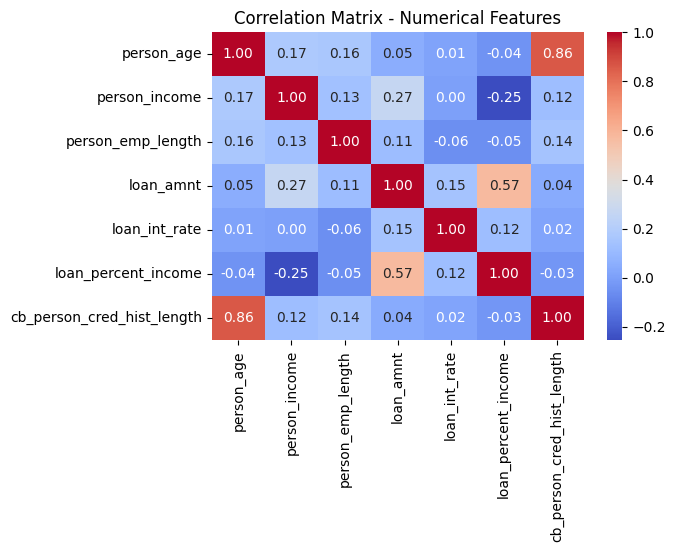

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix - Numerical Features")
plt.show()

### Step 11: Data Leakage Check

First understand what data leakage is:
A feature directly reveals the target before prediction. Model learns to cheat instead of learn real patterns.

In [116]:
# Ensure loan_status is included
corr_matrix = df[numerical_cols + ['loan_status']].corr()

# Get correlation of numerical features with target
target_corr = corr_matrix['loan_status'].drop('loan_status')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print(target_corr_sorted)

loan_percent_income           0.379366
loan_int_rate                 0.335133
person_income                 0.144449
loan_amnt                     0.105376
person_emp_length             0.082489
person_age                    0.021629
cb_person_cred_hist_length    0.015529
Name: loan_status, dtype: float64


### Step 12: Save Validation Report

In [1]:
# see validation_report.md file in docs